

Task: classify 48x48 face images into 7 emotions.

Plan: small CNN first, then better CNNs, log runs to Wandb.

### setup

Imports and paths.

In [16]:
# Uncomment in Colab if packages are missing.
# !pip install torch torchvision scikit-learn matplotlib seaborn tqdm wandb

In [17]:
from pathlib import Path
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from tqdm.auto import tqdm

import wandb

sns.set_theme(style="whitegrid")

In [18]:
SEED = 42
DATA_DIR = Path("../data/fer2013") if Path("../data/fer2013").exists() else Path("data/fer2013")
OUTPUT_DIR = Path("../outputs") if Path("../data/fer2013").exists() else Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device, DATA_DIR

(device(type='cpu'), WindowsPath('../data/fer2013'))

### data

Using the FER2013 folder dataset from Kaggle. The old competition download did not work for me. i couldnt get that data kagle was not allowing me to download any of it or use it on their site.

Expected structure:

```text
data/fer2013/train/<emotion>/*.jpg
data/fer2013/test/<emotion>/*.jpg
```

In [19]:
assert (DATA_DIR / "train").exists(), f"Missing train folder: {DATA_DIR / 'train'}"
assert (DATA_DIR / "test").exists(), f"Missing test folder: {DATA_DIR / 'test'}"

class_names = sorted([p.name for p in (DATA_DIR / "train").iterdir() if p.is_dir()])
class_names

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

In [20]:
train_counts = {c: len(list((DATA_DIR / "train" / c).glob("*.jpg"))) for c in class_names}
test_counts = {c: len(list((DATA_DIR / "test" / c).glob("*.jpg"))) for c in class_names}

print("Train images:", sum(train_counts.values()), train_counts)
print("Test images:", sum(test_counts.values()), test_counts)

Train images: 28709 {'angry': 3995, 'disgust': 436, 'fear': 4097, 'happy': 7215, 'neutral': 4965, 'sad': 4830, 'surprise': 3171}
Test images: 7178 {'angry': 958, 'disgust': 111, 'fear': 1024, 'happy': 1774, 'neutral': 1233, 'sad': 1247, 'surprise': 831}


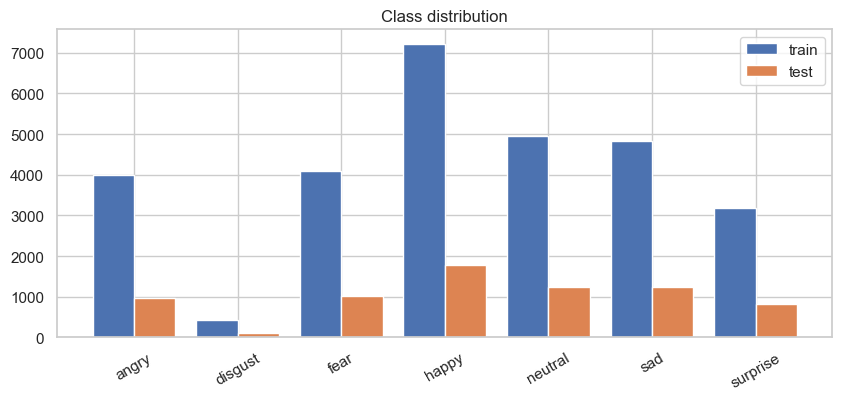

In [21]:
plt.figure(figsize=(10, 4))
x = np.arange(len(class_names))
plt.bar(x - 0.2, [train_counts[c] for c in class_names], width=0.4, label="train")
plt.bar(x + 0.2, [test_counts[c] for c in class_names], width=0.4, label="test")
plt.xticks(x, class_names, rotation=30)
plt.title("Class distribution")
plt.legend()
plt.show()

Classes are not balanced. `happy` has many images, `disgust` has very few. So I should look at the confusion matrix too, not only accuracy.

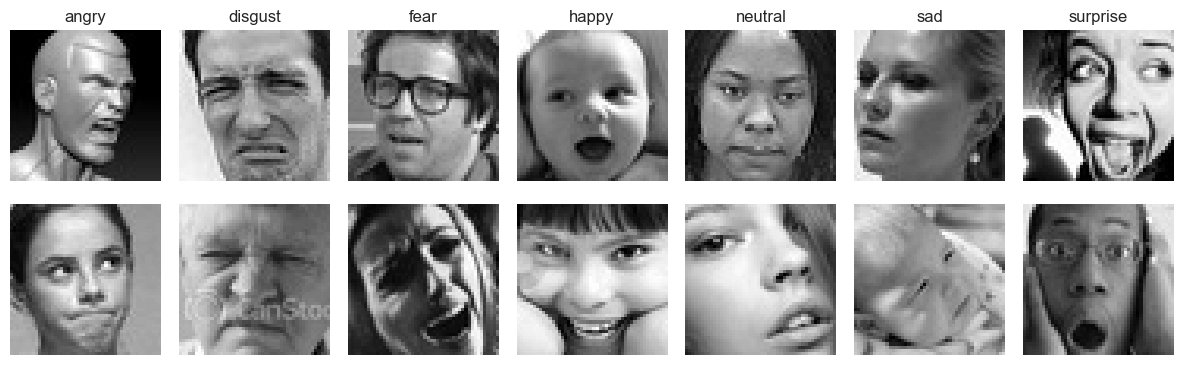

In [22]:
basic_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

preview_dataset = datasets.ImageFolder(DATA_DIR / "train", transform=basic_transform)

fig, axes = plt.subplots(2, 7, figsize=(12, 4))
for label_idx, cls in enumerate(preview_dataset.classes):
    indices = [i for i, (_, y) in enumerate(preview_dataset.samples) if y == label_idx]
    for row in range(2):
        img, y = preview_dataset[random.choice(indices)]
        axes[row, label_idx].imshow(img.squeeze().numpy(), cmap="gray")
        axes[row, label_idx].axis("off")
        if row == 0:
            axes[row, label_idx].set_title(cls)
plt.tight_layout()
plt.show()

### loaders

First run has no augmentation. Later runs use flip/rotation/shift.

In [23]:
def make_transforms(augment=False):
    train_steps = [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((48, 48)),
    ]
    if augment:
        train_steps += [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.RandomAffine(degrees=0, translate=(0.08, 0.08)),
        ]
    train_steps += [
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ]
    eval_steps = [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((48, 48)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ]
    return transforms.Compose(train_steps), transforms.Compose(eval_steps)

def make_loaders(batch_size=128, augment=False, num_workers=2):
    train_transform, eval_transform = make_transforms(augment=augment)
    train_ds = datasets.ImageFolder(DATA_DIR / "train", transform=train_transform)
    test_ds = datasets.ImageFolder(DATA_DIR / "test", transform=eval_transform)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    return train_loader, test_loader, train_ds.classes

### models

Three models, from simple to stronger.

1. **TinyCNN**: baseline.
2. **BetterCNN**: deeper + BatchNorm + Dropout.
3. **ResidualCNN**: small residual model.

In [24]:
class TinyCNN(nn.Module):
    def __init__(self, num_classes=7, dropout=0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(64 * 12 * 12, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
    def forward(self, x):
        return self.block(x)


class BetterCNN(nn.Module):
    def __init__(self, num_classes=7, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
            ConvBlock(128, 256),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256 * 3 * 3, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))


class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.relu(x + self.block(x))


class ResidualCNN(nn.Module):
    def __init__(self, num_classes=7, dropout=0.4):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.stage1 = nn.Sequential(ResidualBlock(32), nn.MaxPool2d(2))
        self.proj1 = nn.Sequential(nn.Conv2d(32, 64, kernel_size=1, bias=False), nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.stage2 = nn.Sequential(ResidualBlock(64), nn.MaxPool2d(2))
        self.proj2 = nn.Sequential(nn.Conv2d(64, 128, kernel_size=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(inplace=True))
        self.stage3 = nn.Sequential(ResidualBlock(128), nn.MaxPool2d(2))
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(), nn.Dropout(dropout), nn.Linear(128, num_classes))
    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.proj1(x)
        x = self.stage2(x)
        x = self.proj2(x)
        x = self.stage3(x)
        return self.head(x)


def build_model(model_name, dropout):
    if model_name == "tiny_cnn":
        return TinyCNN(num_classes=7, dropout=dropout)
    if model_name == "better_cnn":
        return BetterCNN(num_classes=7, dropout=dropout)
    if model_name == "residual_cnn":
        return ResidualCNN(num_classes=7, dropout=dropout)
    raise ValueError(model_name)

### checks

One batch check before training: output shape, loss, gradients.

In [25]:
def sanity_check(model, loader):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    images, labels = next(iter(loader))
    images, labels = images.to(device), labels.to(device)

    logits = model(images)
    loss = criterion(logits, labels)
    loss.backward()

    assert logits.shape == (images.size(0), 7), f"Bad logits shape: {logits.shape}"
    grad_ok = [p.grad is not None and torch.isfinite(p.grad).all().item() for p in model.parameters() if p.requires_grad]
    assert all(grad_ok), "Some gradients are missing or not finite"
    model.zero_grad(set_to_none=True)
    print("Forward/backward check passed:", logits.shape, "loss=", float(loss.detach().cpu()))

tmp_loader, _, _ = make_loaders(batch_size=16, augment=False, num_workers=0)
sanity_check(TinyCNN(), tmp_loader)

Forward/backward check passed: torch.Size([16, 7]) loss= 1.923936128616333


C:\Users\User\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


### train code

Train/eval functions. Every experiment gets a separate Wandb run.

In [26]:
def accuracy_from_logits(logits, labels):
    return (logits.argmax(dim=1) == labels).float().mean().item()

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, total_correct, total_count = 0.0, 0, 0
    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_count += images.size(0)
    return total_loss / total_count, total_correct / total_count

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_count = 0.0, 0, 0
    all_labels, all_preds = [], []
    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        preds = logits.argmax(dim=1)

        total_loss += loss.item() * images.size(0)
        total_correct += (preds == labels).sum().item()
        total_count += images.size(0)
        all_labels.extend(labels.cpu().tolist())
        all_preds.extend(preds.cpu().tolist())
    return total_loss / total_count, total_correct / total_count, all_labels, all_preds

def make_optimizer(model, optimizer_name, lr, weight_decay):
    if optimizer_name == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if optimizer_name == "adamw":
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    raise ValueError(optimizer_name)

In [27]:
def run_experiment(config, use_wandb=True):
    set_seed(config.get("seed", SEED))
    train_loader, test_loader, classes = make_loaders(
        batch_size=config["batch_size"],
        augment=config["augment"],
        num_workers=config.get("num_workers", 2),
    )
    model = build_model(config["model"], dropout=config["dropout"]).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(model, config["optimizer"], config["learning_rate"], config["weight_decay"])

    sanity_check(model, train_loader)
    optimizer.zero_grad(set_to_none=True)

    run = None
    if use_wandb:
        run = wandb.init(project="fer2013-homework", name=config["run_name"], config=config)
        wandb.watch(model, log="gradients", log_freq=100)

    best_acc = 0.0
    best_path = OUTPUT_DIR / f"{config['run_name']}_best.pt"
    history = []

    for epoch in range(1, config["epochs"] + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, labels, preds = evaluate(model, test_loader, criterion)
        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        }
        history.append(row)
        print(row)

        if use_wandb:
            wandb.log({
                "epoch": epoch,
                "train/loss": train_loss,
                "train/accuracy": train_acc,
                "val/loss": val_loss,
                "val/accuracy": val_acc,
            })

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save({"state_dict": model.state_dict(), "config": config, "classes": classes, "best_acc": best_acc}, best_path)

    val_loss, val_acc, labels, preds = evaluate(model, test_loader, criterion)
    print(classification_report(labels, preds, target_names=classes))

    if use_wandb:
        wandb.log({
            "final/accuracy": val_acc,
            "final/confusion_matrix": wandb.plot.confusion_matrix(y_true=labels, preds=preds, class_names=classes),
        })
        run.summary["best_val_accuracy"] = best_acc
        run.summary["best_checkpoint"] = str(best_path)
        run.finish()

    return {"config": config, "history": history, "best_acc": best_acc, "labels": labels, "preds": preds, "checkpoint": best_path}

### small overfit test

Try to overfit 64 images. If loss does not go down, something is wrong.

epoch=01 loss=1.9245 acc=0.1875


epoch=02 loss=1.7282 acc=0.2812


epoch=03 loss=1.6279 acc=0.3594


epoch=04 loss=1.4973 acc=0.4844


epoch=05 loss=1.3859 acc=0.5469


...

epoch=16 loss=0.1016 acc=1.0000


epoch=17 loss=0.0658 acc=1.0000


epoch=18 loss=0.0663 acc=0.9844


epoch=19 loss=0.0363 acc=1.0000


epoch=20 loss=0.0302 acc=1.0000


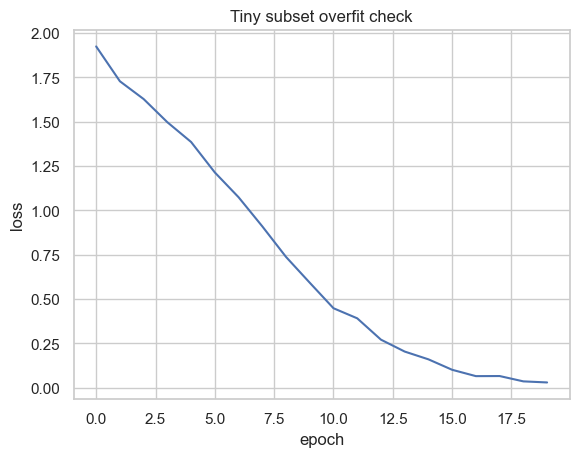

In [28]:
def overfit_tiny_subset(model_class=TinyCNN, n_samples=64, epochs=20):
    train_transform, _ = make_transforms(augment=False)
    full_ds = datasets.ImageFolder(DATA_DIR / "train", transform=train_transform)
    rng = np.random.default_rng(SEED)
    indices = rng.choice(len(full_ds), size=n_samples, replace=False).tolist()
    tiny_ds = Subset(full_ds, indices)
    tiny_loader = DataLoader(tiny_ds, batch_size=32, shuffle=True, num_workers=0)

    model = model_class().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    losses = []
    for epoch in range(epochs):
        loss, acc = train_one_epoch(model, tiny_loader, criterion, optimizer)
        losses.append(loss)
        print(f"epoch={epoch+1:02d} loss={loss:.4f} acc={acc:.4f}")
    plt.plot(losses)
    plt.title("Tiny subset overfit check")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.show()


overfit_tiny_subset()

### experiments

Main runs. These three are the architecture comparison.

In [ ]:
experiments = [
    {
        "run_name": "tiny_cnn_lr1e-3",
        "model": "tiny_cnn",
        "epochs": 10,
        "batch_size": 128,
        "learning_rate": 1e-3,
        "weight_decay": 0.0,
        "optimizer": "adam",
        "dropout": 0.25,
        "augment": False,
        "seed": SEED,
        "num_workers": 2,
        "decision": "Small baseline. I expect it to learn basic edges/textures but underfit the task.",
    },
    {
        "run_name": "better_cnn_aug_dropout03",
        "model": "better_cnn",
        "epochs": 20,
        "batch_size": 128,
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "optimizer": "adamw",
        "dropout": 0.30,
        "augment": True,
        "seed": SEED,
        "num_workers": 2,
        "decision": "Adds BatchNorm, more capacity, augmentation, and weight decay to fight overfitting.",
    },
    {
        "run_name": "residual_cnn_adamw_lr3e-4",
        "model": "residual_cnn",
        "epochs": 30,
        "batch_size": 128,
        "learning_rate": 3e-4,
        "weight_decay": 5e-4,
        "optimizer": "adamw",
        "dropout": 0.40,
        "augment": True,
        "seed": SEED,
        "num_workers": 2,
        "decision": "Tests residual blocks and lower learning rate for a more stable deeper model.",
    },
]

for exp in experiments:
    print(exp["run_name"], "-", exp["decision"])

### run

Run `wandb.login()` first. For testing notebook only, set `USE_WANDB = False`.

In [ ]:
# wandb.login()

USE_WANDB = True
RUN_ALL_EXPERIMENTS = True  
experiments[0]["epochs"] = 3
experiments[1]["epochs"] = 5
experiments[2]["epochs"] = 5
results = []
if RUN_ALL_EXPERIMENTS:
    for config in experiments:
        print("\nStarting", config["run_name"])
        result = run_experiment(config, use_wandb=USE_WANDB)
        results.append(result)

Debug cell for one short run.

In [ ]:
# Single-run debug example:
# debug_config = experiments[0].copy()
# debug_config["epochs"] = 1
# debug_result = run_experiment(debug_config, use_wandb=False)

### results

Fill this after training.

| Run | Architecture | LR | Dropout | Augmentation | Best val/test accuracy | Notes |
| --- | --- | ---: | ---: | --- | ---: | --- |
| `tiny_cnn_lr1e-3` | TinyCNN | 0.001 | 0.25 | no | TODO | Baseline |
| `better_cnn_aug_dropout03` | BetterCNN | 0.001 | 0.30 | yes | TODO | More capacity + regularization |
| `residual_cnn_adamw_lr3e-4` | ResidualCNN | 0.0003 | 0.40 | yes | TODO | Residual blocks + stronger regularization |

In [ ]:
if results:
    names = [r["config"]["run_name"] for r in results]
    scores = [r["best_acc"] for r in results]
    plt.figure(figsize=(8, 4))
    plt.bar(names, scores)
    plt.xticks(rotation=20, ha="right")
    plt.ylabel("Best accuracy")
    plt.title("Experiment comparison")
    plt.ylim(0, 1)
    plt.show()

In [ ]:
if results:
    best = max(results, key=lambda r: r["best_acc"])
    cm = confusion_matrix(best["labels"], best["preds"])
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion matrix: {best['config']['run_name']}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

### final notes

After training, copy scores and Wandb links into `README.md`.

Before running, my guess:

- TinyCNN should be the weakest but is useful as a baseline.
- BetterCNN should improve because it has more feature capacity and regularization.
- ResidualCNN may improve further, but if it does not, that is still useful: it means extra architecture complexity did not beat the simpler tuned CNN under my training budget.

Main thing: show what I tried and whether it helped.